Napredna analiza podataka - Projekat - Klasifikacija teksta

Detekcija Spam mejlova na osnovu sadržaja mejla - BoW + MultinomialBayes

Instalacija potrebnih biblioteka

In [61]:
!pip install -r ../requirements.txt

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sb

Prvobitno učitavanje dataset-a sa dodatnim informacijama o broju unikatnih vrednosti opservacija

Napomena - pri višestrukom ponavljanju ove analize zaklučio sam da je dataset pun duplikata, jedan od razloga za to je zato što je ovaj dataset prikupljen korišćenjem honeypot mejlova. Ovo je imalo za posledicu da moji modeli imaju preciznost od 99%, tako da sam odlučio da odbacim što više duplikata tako da bi model bio generalizovan i treniran na heterogenim terminima u mejlovima.

In [63]:
data = pd.read_csv('../data/emails/CEAS_08.csv')
data = data.drop_duplicates(subset=['subject'], keep='first')
data = data.drop_duplicates(subset=['body'], keep='first')
data = data.drop_duplicates(subset=['sender','receiver'],keep='first')

U datom datasetu postoje sledeće promenljive:
Sender - Naziv pošiljaoca  i mejl adresa
Receiver - mejl adresa primaoca
Date - datum slanja
Subject - naslov mejla
Body - sadržaj mejla
Label - binarna promenljiva koja označava da li je mejl spam ili ne. 1 je spam dok 0 nije.
Urls - binarna promenljiva koja označava da li se u mejlu nalaze url-ovi

Osnovne informacije o dataset-u

In [64]:
data.info()

<class 'pandas.DataFrame'>
Index: 11185 entries, 0 to 39151
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    11185 non-null  str  
 1   receiver  11102 non-null  str  
 2   date      11185 non-null  str  
 3   subject   11184 non-null  str  
 4   body      11185 non-null  str  
 5   label     11185 non-null  int64
 6   urls      11185 non-null  int64
dtypes: int64(2), str(5)
memory usage: 699.1 KB


Izvlačenje obeležja - Feature extraction

In [65]:
data.receiver.value_counts()

receiver
user6@gvc.ceas-challenge.cc                                               397
user2.2@gvc.ceas-challenge.cc                                             395
user2.4@gvc.ceas-challenge.cc                                             299
user7-ext4@gvc.ceas-challenge.cc                                          292
user2.13@gvc.ceas-challenge.cc                                            291
                                                                         ... 
Christian Campbell <yekxpbaab@brueggers.com>                                1
Rich Neo <bf-jgyyrpxggb@neiu.edu>                                           1
Dave Koontz <fcquqwd@mbc.edu>                                               1
"Maier,Chris" <dmeuc.tpvnl@heb.com>                                         1
rgkwpdahmhmail@cs.cmu.edu, faq@engr.orst.edu, ji-ivay@googlegroups.com      1
Name: count, Length: 1954, dtype: int64

Kao sto se može videti, veliki broj mejlova ima iste primaoce, pretpostavljam da su ovi mejlovi služili kao honeypot-ovi za prikupljanje spam napada. Podaci primaoca se onda teško mogu koristiti za klasifikaciju.

Postoji rizik od overfitting-a, ukoliko treniram model na ovim podacima. Jedino za šta bi mogla da mi služi promenljiva primaoc je da se na primer poredi adresa primaoca i pošiljaoca. Ukoliko su mejl serveri isti, onda postoji veća šansa da je mejl validan

Probaću da nađem mejlove(opservacije) koje sadrže isti mejl servera pošiljaoca i primaoca

In [66]:
sender_domain = data['sender'].str.split("@").str[1].str.removesuffix(">")
receiver_domain = data['receiver'].str.split("@").str[1].str.removesuffix(">")

internal_sending_data = data.loc[sender_domain == receiver_domain]
internal_sending_data

,sender,receiver,date,subject,body,label,urls
22,ohwwlejs-pbfotbp@list.scms.waikato.ac.nz,iuxxdkqk@list.scms.waikato.ac.nz,"Tue, 05 Aug 2008 18:32:19 -0500","Wekalist Digest, Vol 60, Issue 10",Send Wekalist mailing list submissions to\n\ti...,0,1
54,Perl Jobs <xycn-vtnhz@perl.org>,necc@perl.org,"Tue, 05 Aug 2008 02:47:22 -0800","[Perl Jobs] Perl developer, Hungary, Budapest",Online URL for this job: http://jobs.perl.org/...,0,1
88,"""Mickisch, Freda"" <e.bsnrgtrf@massey.ac.nz>",yrvc-tke@massey.ac.nz,"Wed, 06 Aug 2008 12:34:55 +1300",Supervisors PhD students: 6-monthly reports...,Hi \n\n \n\nJust a reminder that these are due...,0,0
102,user2.13@gvc.ceas-challenge.cc,user2.13@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 14:36:16 -0400",Angelina Jolie Free Video.,\n\n\n\n\n\n\n\n\n\n\n\nFree Video Nude Anjeli...,1,0
123,demerphq <oryiufjn@gmail.com>,Rafael Garcia-Suarez <pvhuhqgncrxnu@gmail.com>,"Wed, 06 Aug 2008 01:36:57 +0200",Re: Regex issue with scoping in loops.,"On 10/3/07, Rafael Garcia-Suarez wrote:\n> On...",0,1
...,...,...,...,...,...,...,...
38265,Rafael Garcia-Suarez <pvhuhqgncrxnu@gmail.com>,Jim Cromie <boj.keyldk@gmail.com>,"Fri, 08 Aug 2008 13:40:30 +0100","Re: rc1 patch - delta, comment nits","On 19/11/2007, Jim Cromie wrote:\n> several n...",0,0
38467,Proinnsias Breathnach <vfnkdycxsy@linux.ie>,Irish Linux Users Group <qifw@linux.ie>,"Fri, 08 Aug 2008 12:56:39 +0000",Re: [ILUG] Splitting a large csv file,"On Mon, Nov 19, 2007 at 03:37:53PM +0000, Thom...",0,0
38531,sypbqa@firstcontact.net.nz,rmcmy@firstcontact.net.nz,"Sat, 09 Aug 2008 01:01:31 +1200",nzherald.co.nz - Apple's iPhone to be offered ...,\nDebbie Larkins thought you would be interest...,0,0
38686,Doron Peled <wzuggn@macs.biu.ac.il>,rlbkufgibjz-jiuz@macs.biu.ac.il,"Fri, 08 Aug 2008 15:15:15 +0200",[UAI] CFP: 5th Workshop on Model Checking and AI,- Call for Papers -\n...,0,1


In [67]:
internal_sent = internal_sending_data.loc[internal_sending_data['label'] == 0]
print(f"Ukupan broj internih mejlova koji nisu phising: {len(internal_sent)} od {len(internal_sending_data)}")

Ukupan broj internih mejlova koji nisu phising: 276 od 295


In [68]:
data['is_internal'] = sender_domain == receiver_domain
data['is_internal'] = data['is_internal'].map({True:1,False: 0})

Kao što se može videti veliki broj izdvojenih mejlova su zaista rezultat internog slanja. Nije veliki broj ovakvih mejlova ali predstavljaju bitan podatak za povećanje sigurnosti bezbednog mejla. Moguće je izvršiti transformaciju gde će se dodati binarna promenljiva is_internal. Zaključujem da postoji velika korelacija između poklapanja serverskih domena i status spam-a

Sledeće što se može proveriti je kako izgledaju opservacije koje nemaju specificiranog primaoca, ovakvi mejlovi obično predstavljaju spam ako su mejlovi samo navedeni u bcc

In [69]:
no_recipient_mails = data.loc[data['receiver'].isna() == True]
no_recipient_mails

,sender,receiver,date,subject,body,label,urls,is_internal
620,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:05:33 +0100",Re: SASL questions,"AlxFrag wrote:\n> Hi,\n>\n> i have a couple of...",0,0,0
2043,jdd <xyi@dodin.org>,NaN,"Wed, 06 Aug 2008 02:29:48 +0100",Re: [opensuse] Re: openSUSE Boxed Editions,Aaron Kulkis a écrit :\n\n> so that the primar...,0,1,0
4354,u.dgfphz@massey.ac.nz,NaN,"Wed, 06 Aug 2008 16:55:08 +1300",Professorial Lecture - 6th March,Hi Everyone\n\nI would like to remind you of t...,0,1,0
4548,Gabriel Genellina <ynuffj-wvo@phaseit.net>,NaN,"Tue, 05 Aug 2008 05:27:12 +0000",Python-URL! - weekly Python news and links (Fe...,"QOTW: ""I think not enough is made of the fact...",0,1,0
4557,Tim Golden <cggc@timgolden.me.uk>,NaN,"Wed, 06 Aug 2008 04:22:28 +0000",Re: [python-win32] Launching a New Instance of...,Jon Peck wrote:\n> We need to launch Excel fro...,0,1,0
...,...,...,...,...,...,...,...,...
33406,Jan Peters <cggc@jan-peters.net>,NaN,"Fri, 08 Aug 2008 06:18:56 +0200",[UAI] NIPS 2007 WORKSHOP: Robotics Challenges ...,*** Apologies for Multipl...,0,1,0
34498,jdd <xyi@opensuse.org>,NaN,"Fri, 08 Aug 2008 07:53:06 +0100",Re: [opensuse] [OT] unstable system - still t...,Per Jessen a écrit :\n\n> So now what?\n\nI've...,0,1,0
34874,Gryffus <ddxhffe@hkfree.org>,NaN,"Fri, 08 Aug 2008 08:39:18 +0100",Re: [opensuse] Kernel version questions,Or you can trust to community. Just fire-up ya...,0,1,0
34898,Agnello George <nydnuik.hhtbfx@gmail.com>,NaN,"Fri, 08 Aug 2008 13:11:16 +0530",Re: logrotate query !,"On 3/4/08, Martin Gregorie wrote:\n>\n> On Mo...",0,0,0


In [70]:
no_recipient_mails_ham = no_recipient_mails.loc[no_recipient_mails['label'] == 0]
print(f"Ukupan broj mejlova bez primaoca koji nisu spam: {len(no_recipient_mails_ham)} od {len(no_recipient_mails)}")

Ukupan broj mejlova bez primaoca koji nisu spam: 81 od 83


Moja početna tvrdnja ipak nije bila tačna, tako da ću odstraniti mejlove koje nemaju vrednost primaoca

In [71]:
data.dropna(axis=0,subset=['receiver'],inplace=True)

Sledeća promenljiva koju posmatram je date promenljiva. Treniranjem modela nad ovom promenljivom, predstavlja veliki rizik za overfitting modela i datumi su iz 2008 godine. Jedino kako mislim da bi se ova promenljiva mogla koristiti je tako da se izdvoje dani u nedelji i nauči model kada su napadi najčeši.

In [72]:
data['date'] = pd.to_datetime(data['date'], format="%a, %d %b %Y %H:%M:%S %z",utc=True, errors='coerce')

In [73]:
data.info()

<class 'pandas.DataFrame'>
Index: 11102 entries, 0 to 39151
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   sender       11102 non-null  str                
 1   receiver     11102 non-null  str                
 2   date         11090 non-null  datetime64[us, UTC]
 3   subject      11101 non-null  str                
 4   body         11102 non-null  str                
 5   label        11102 non-null  int64              
 6   urls         11102 non-null  int64              
 7   is_internal  11102 non-null  int64              
dtypes: datetime64[us, UTC](1), int64(3), str(4)
memory usage: 780.6 KB


In [74]:
data['day_of_week'] = data['date'].dt.strftime("%a")

In [75]:
data['day_of_week'] = data['day_of_week'].map({'Sun':0,'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat': 5})

Isto ću uraditi i za časove u toku dana

In [76]:
data['hour_of_day'] = data['date'].dt.strftime("%H")

Pošto sam izveo promenljive iz datetime-a za analizu, odbaciću originalnu promenljivu datetime

In [77]:
data.drop(columns=['date'],inplace=True)

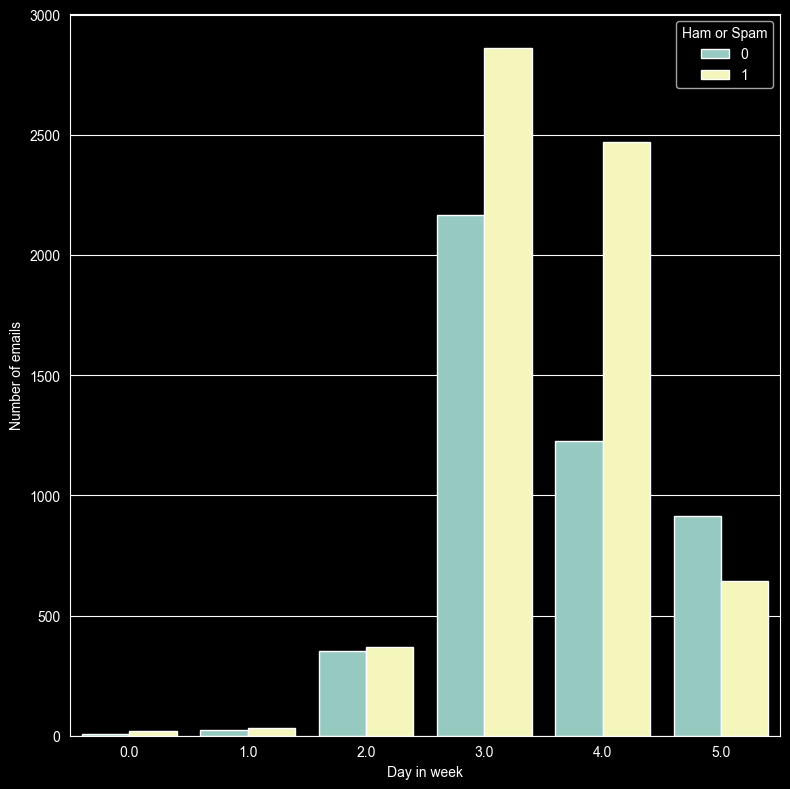

In [78]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='day_of_week',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Nisam siguran na osnovu grafikona da procenim da li se raspodele razlikuju, pa ću primeniti Hi-kvadrat test da utvrdim koliko je jaka veza izmedju dva kategorička obeležja

In [79]:
from scipy.stats import chi2_contingency
crosstab = pd.crosstab(data['day_of_week'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 9.481312932643401e-66


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost između ove dve promenljive. Zadržaću ovu promenljivu

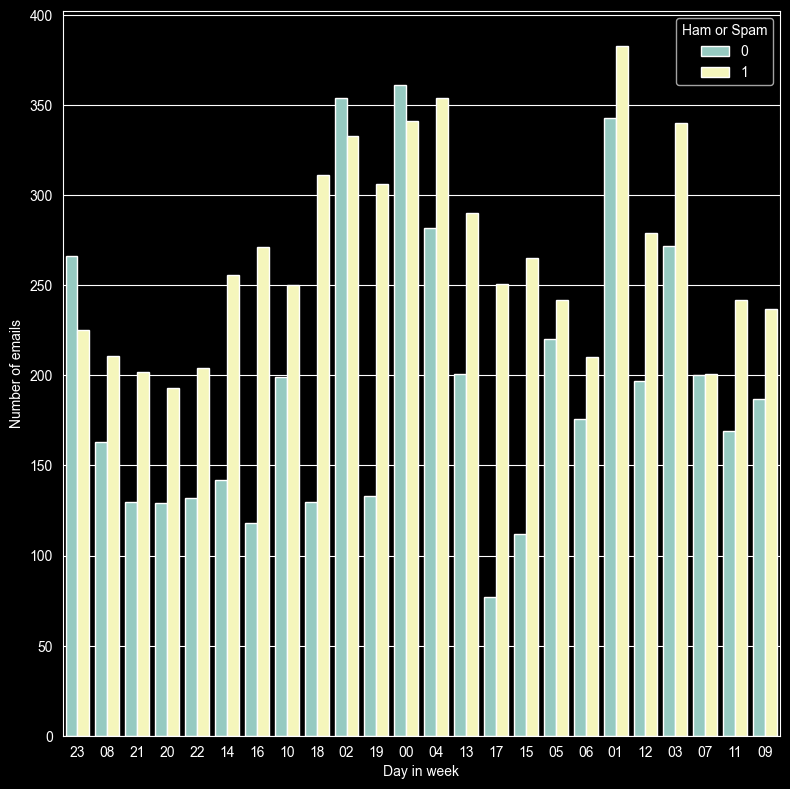

In [80]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='hour_of_day',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Sa grafikona već mogu da vidim da se raspodele časova u odnosu na labelu razilikuju. Ali za svaki slučaj ću primeniti Hi kvadrat test da ovo potvrdim

In [81]:
crosstab = pd.crosstab(data['hour_of_day'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 3.853855045534494e-43


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost izmedju ove dve promenljive. Zadržaću ovu promenljivu

Izdvajanje obeležja - Subject

Na osnovu deteljnog pregleda dataset-a može se primetiti veliki broj reply mejlova koji su u formatu Re: (odgovor). Takođe postoji veliki broj mejlova koji u naslovu sadrže neku vrstu zaglavlja tipa [Perl Jobs], ova obeležja zajedno sa forward formatom predstavljaju snažan indikator da ovi mejlovi nisu spam. Koristiću regex-e da izvučem ova obeležja

In [82]:
import re
# Prihvata formate Re: tekst i Re tekst
are_replies = data[data['subject'].str.match(r"^Re[:\s]\s*",flags=re.IGNORECASE,na=False)]
ham_replies = are_replies.loc[are_replies['label'] == 0]
print(f"{len(ham_replies)} od {len(are_replies)} mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi")

# Prihvata Fw, Fwd, Fw:, Fwd: u mejlovima
are_forwards = data[data['subject'].str.contains(r"Fwd?[:\s]\s*",flags=re.IGNORECASE,na = False)]
ham_are_forwards = are_forwards.loc[are_forwards['label']==0]
print(f"{len(ham_are_forwards)} od {len(are_forwards)} mejlova koji sadrze Fw (kao forward) zaista nisu spam mejlovi")

# Prihvata formate [Perl Jobs]
subject_metadata = data[data['subject'].str.contains(r"\[.*?\]",na=False)]
ham_subject_metadata = subject_metadata.loc[subject_metadata['label'] == 0]
print(f"{len(ham_subject_metadata)} od {len(subject_metadata)} mejlova koji sadrze meta podatke u formatu [*] zaista nisu spam mejlovi")

1395 od 1467 mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi
93 od 129 mejlova koji sadrze Fw (kao forward) zaista nisu spam mejlovi
2845 od 2855 mejlova koji sadrze meta podatke u formatu [*] zaista nisu spam mejlovi


In [83]:
data['is_reply'] = data['subject'].str.match(r"^Re\s*",flags=re.IGNORECASE,na=False).astype(int)
data['has_subject_header'] = data['subject'].str.contains(r"\[.*?\]",na=False).astype(int)
data['is_forward'] = data['subject'].str.contains(r"Fw\s*",flags=re.IGNORECASE,na=False).astype(int)

In [84]:
data[['subject','is_reply','has_subject_header','is_forward','label']].sample(10)

,subject,is_reply,has_subject_header,is_forward,label
9111,Add inches in diameter as well as length!,0,0,0,1
33853,Whiskas Scratching Post,0,0,0,0
30526,[UAI] CFP: Evaluating Architectures for Intel...,0,1,0,0
28783,SafeSecureForCustomersPharm,0,0,0,1
3197,Re: Bayes - Balance of spam,1,0,0,0
5526,Villas for rent,0,0,0,1
320,*3 FREE Bottles Of VPXL !!,0,0,0,1
13541,Say goodbuy to bad bad condition,0,0,0,1
19046,[ANN] Twisted 8.0,0,1,0,0
31553,[SM-DEVEL] Sorting by From / Sender field - in...,0,1,0,0


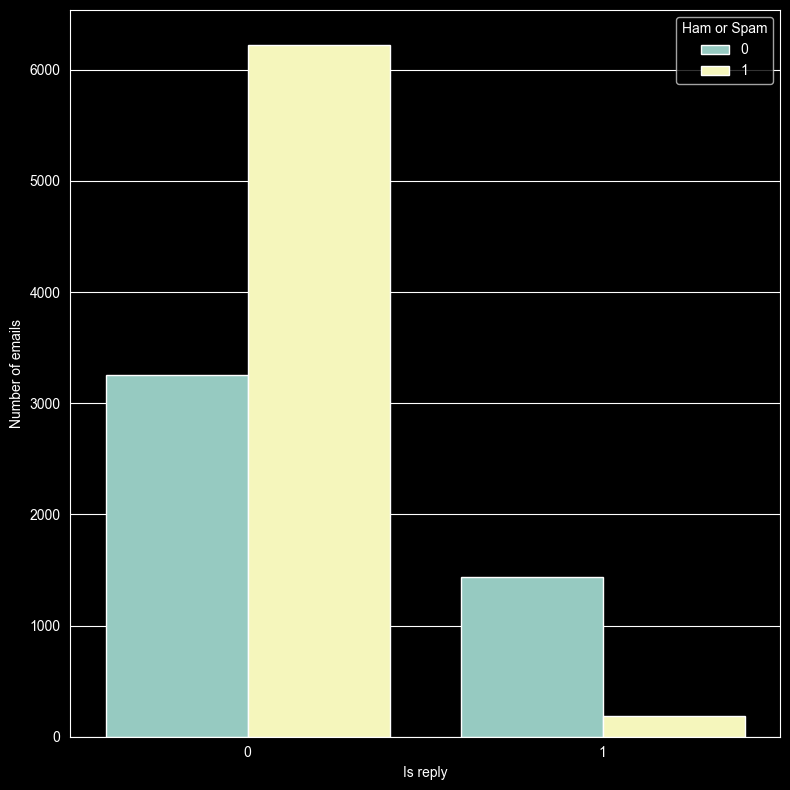

In [85]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='is_reply',hue='label')
plt.xlabel('Is reply')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodele promenljive is_reply u odnosu na vrednost labele se razlikuju, zbog toga može doprineti razdvajanju klasa. Zadržaću je u analizi

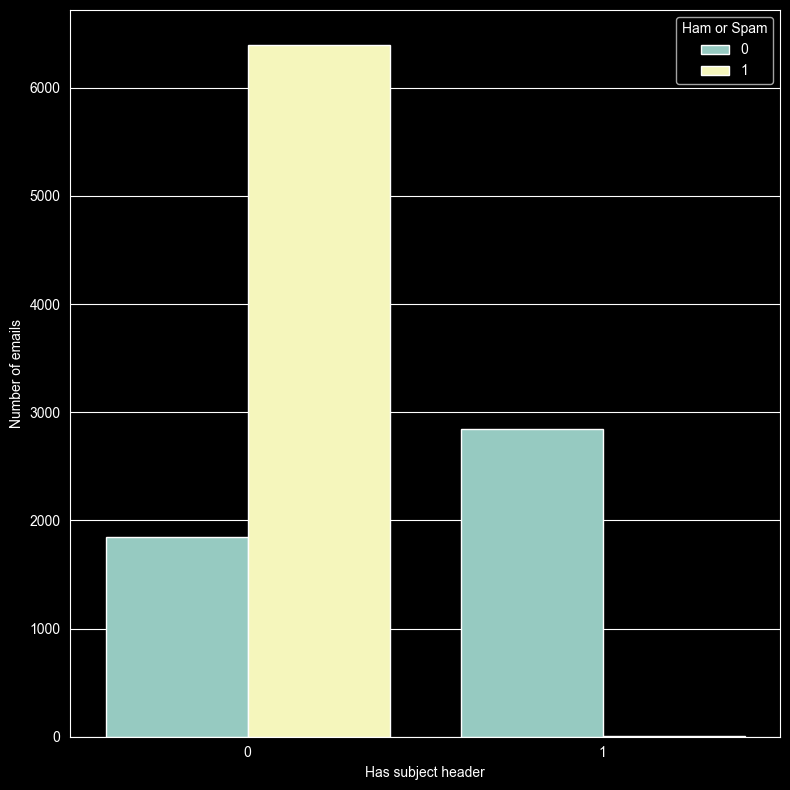

In [86]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='has_subject_header',hue='label')
plt.xlabel('Has subject header')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodela promenljive has_subject_header u odnosu na vrednosti zavisne promenljive se značajno razlikuju, promenljiva može doprineti razdvajanju klasa. Zadržaću je u analizi.


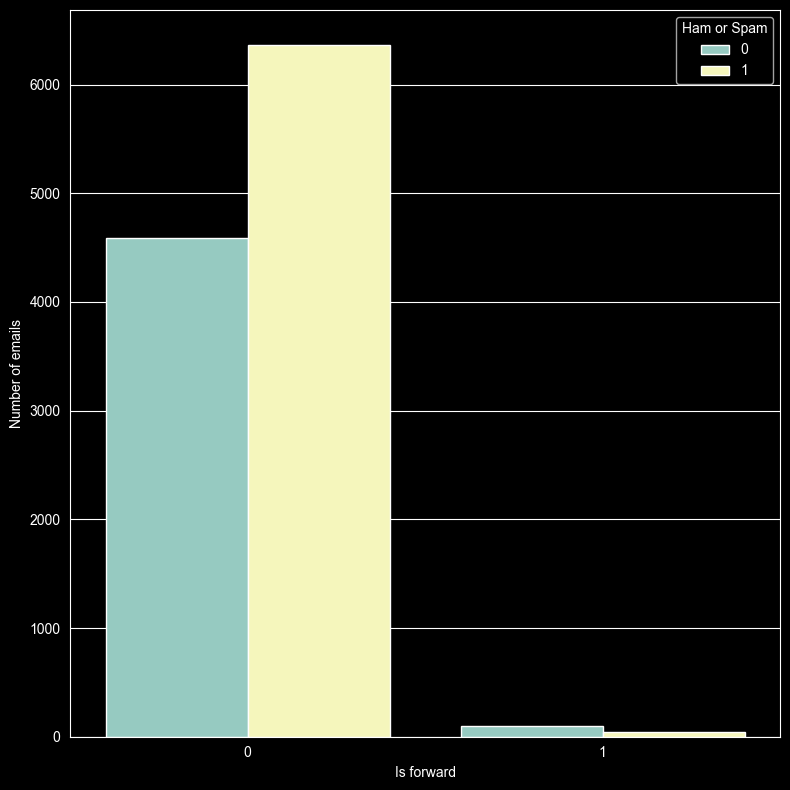

In [87]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='is_forward',hue='label')
plt.xlabel('Is forward')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodela promenljive is_forward u odnosu na vrednosti zavisne promenljive se značajno razlikuju, promenljiva može doprineti razdvajanju klasa. Zadržaću je u analizi.


Izdvajanje obeležja - Sender


Promenljiva sender ima sledeći oblik NazivPosiljaoca EmailAdresa. Naziv posiljaoca mi nije od velikog znacaja kao ni korisničko ime, jedino što će mi omogućiti da utvrdim da li je spam mejl ili ne je domen mejl servera.

Sender - provericu da li mejl server u sebi sadrzi brojeve(npr. m1crosoft.com), jer to često može predstavljati ključan indikator spam mejlova. Opet sama adresa pošiljaoca neće imati koristi za treniranje modela, ali moguće je izvesti promenljivu na primer has_number_in_sender_server.

In [88]:
def sender_to_email(sender):
    if sender and "<" in sender:
        email = sender.split("<")[1].removesuffix(">")
        return email
    else:
        return ""
data['sender'] = data['sender'].apply(sender_to_email)

In [89]:
def email_to_domain(email):
    if "@" in email:
        domain = email.split("@")[1]
        return domain
    else:
        return ""
data['sender'] = data['sender'].apply(email_to_domain)

Takođe veliki broj spam mejlova u svom domenu sadrži brojeve, klasičan primer pokušaja obmane su mejlovi koji zamenjuju karaktere brojevima, npr. m1crosoft.com

In [90]:
def domain_has_numbers(email):
    if "@" in email:
        email = email.split("@")[1].removesuffix(">")
        return any(char.isdigit() for char in email)
    return False
data['has_number_in_sender_server'] = data['sender'].apply(domain_has_numbers)

In [91]:
data.loc[(data['has_number_in_sender_server'] == True) & (data['label'] == 1)]

,sender,receiver,subject,body,label,urls,is_internal,day_of_week,hour_of_day,is_reply,has_subject_header,is_forward,has_number_in_sender_server


Ovaj dataset izgleda ne poseduje ni jedan mejl koji sadrži domen ovog tipa, promenljiva će ipak biti preskočena

In [92]:
data.drop(labels=['has_number_in_sender_server'],axis=1,inplace=True)

Takođe testiraće se broj poddomena imejl adrese na osnovu tacaka u mejlu, obično profesionalni mejlovi imaju kratke domene

In [93]:
def num_of_dots(domain):
    return domain.count('.')
data['email_dots'] = data['sender'].apply(num_of_dots)

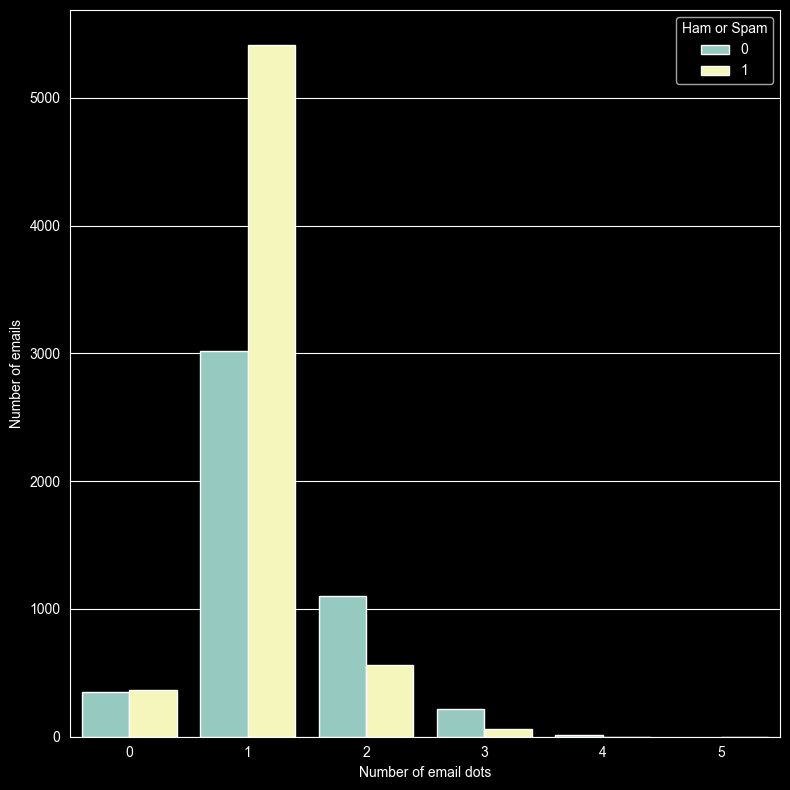

In [94]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='email_dots',hue='label')
plt.xlabel('Number of email dots')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Na osnovu grafikona se moze zaključiti da ova promenljiva ne doprinosi dovoljno razdvajanju klasa, ova promenljiva neće biti razmatrana u analizi

In [95]:
data.drop(labels=['email_dots'],axis=1,inplace=True)

Na kraju ću još proveriti značajnost promenljive url u razdvajanju klasa

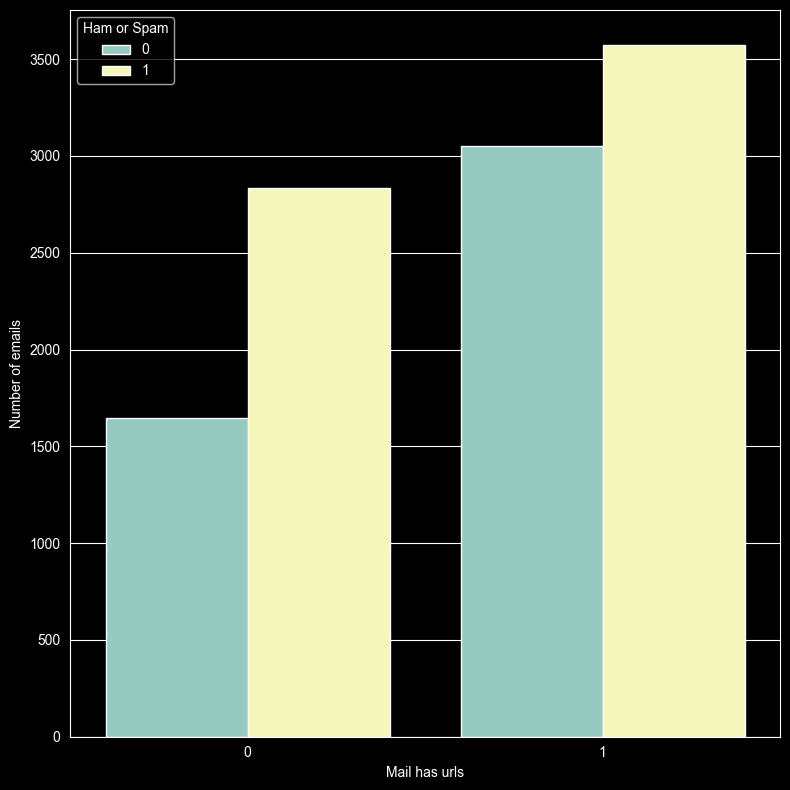

In [96]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='urls',hue='label')
plt.xlabel('Mail has urls')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Iz sender promenljive su izvucena znacanja obelezja za analizu, tako da cu je sad odstraniti posto nema svrhu u daljem treniranju

In [97]:
data.drop(labels=['sender'],axis=1,inplace=True)

In [98]:
data.label.value_counts(normalize=True)

label
1    0.577283
0    0.422717
Name: proportion, dtype: float64

Sobzirom da ne postoji veliki disbalans u izlaznoj promenljivoj, neću koristiti SMOTE metodu balansiranja

Transformacija tekstualnih promenljvih koriscenjem spacy biblioteke

In [99]:
# Za pocetak koristicu najmanji spacy model koji ne podrzava vektorsku repreztaciju teksta, zato sto mi je prvo cilj da testiram uspešnost Bag of Words metode
!python -m spacy download en_core_web_sm
import spacy
nlp_sm = spacy.load('en_core_web_sm',disable=['parser', 'ner'])

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----------- ---------------------------- 3.7/12.8 MB 35.3 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 43.8 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 38.6 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


Kao što sam rekao veliki broj mejlova u dataset-u je šablonski. Kako bih izbegao pristrasnost modela prema nekim rečima koje nisu spam ali su u velikoj količini u spam mejlovima, koristiću predefinisani vokabular spam reči i fraza koji ću proslediti Bow https://mailmeteor.com/blog/spam-words

In [100]:
spam_phrases = [
    "50% off", "a few bob", "accept cash cards", "accept credit cards", "affordable",
    "affordable deal", "avoid bankruptcy", "bad credit", "bank", "bankruptcy",
    "bargain", "billing", "billing address", "billion", "billion dollars",
    "billionaire", "card accepted", "cards accepted", "cash", "cash bonus",
    "cash out", "cash-out", "cashcashcash", "casino", "cents on the dollar",
    "check", "check or money order", "claim your discount", "cost", "costs",
    "credit", "credit bureaus", "credit card", "credit card offers",
    "credit or debit", "deal", "debt", "discount", "dollars", "double your",
    "double your wealth", "earn", "earn $", "earn cash", "earn extra income",
    "earn from home", "earn monthly", "earn per month", "earn per week",
    "earn per year", "easy income", "easy terms", "f r e e", "for free",
    "for just $", "free access", "free consultation", "free gift", "free hosting",
    "free info", "free investment", "free money", "free preview",
    "free quote", "free trial", "full refund", "get out of debt", "giveaway",
    "guaranteed deposit", "increase revenue", "increase sales/traffic",
    "instant earnings", "instant income", "insurance", "investment",
    "investment advice", "loans", "make $", "money-back guarantee", "mortgage",
    "mortgage rates", "offer", "one hundred percent free", "only $", "price",
    "price protection", "profits", "quote", "refinance", "save $", "save big money",
    "subject to credit", "us dollars", "why pay more?", "your income",
    "100% guaranteed", "access now", "act fast", "amazing deal", "apply now",
    "as seen on", "best deal", "big profit", "can’t miss", "click below",
    "click here", "deal ending soon", "don’t delete", "double your money",
    "exclusive deal", "fantastic offer", "free membership", "get it now",
    "great news", "guaranteed results", "important information", "increase sales",
    "instant savings", "limited time", "must read", "new customers only",
    "no catch", "no cost", "no credit check", "no obligation", "no strings attached",
    "once in a lifetime", "only available here", "order now", "potential earnings",
    "pure profit", "risk-free", "special invitation", "special offer",
    "this won’t last", "urgent", "will not believe", "#1", "100% free",
    "100% off", "100% satisfied", "additional income", "amazed", "amazing",
    "amazing offer", "amazing stuff", "be amazed", "be surprised",
    "be your own boss", "best bargain", "best offer", "best price", "best rates",
    "big bucks", "bonus", "can’t live without", "consolidate debt", "double your cash",
    "double your income", "drastically reduced", "earn extra cash", "earn money",
    "expect to earn", "extra", "extra cash", "extra income", "fantastic",
    "fantastic deal", "fast cash", "financial freedom", "free priority mail",
    "get paid", "incredible deal", "join millions", "lowest price", "make money",
    "million dollars", "prize", "promise", "satisfaction guaranteed", "save up to",
    "special promotion", "the best", "thousands", "unbeatable offer",
    "unbelievable", "unlimited", "wonderful", "you will not believe your eyes",
    "access", "act", "act immediately", "act now!", "action", "action required",
    "apply here", "apply now!", "apply online", "become a member",
    "before it’s too late", "being a member", "buy", "buy direct", "buy now",
    "buy today", "call", "call free", "call free/now", "call me", "call now!",
    "can we have a minute of your time?", "cancel now", "cancellation required",
    "claim now", "click", "click me to download", "click now", "click this link",
    "click to get", "click to remove", "contact us immediately", "do it now",
    "do it today", "don’t hesitate", "don’t waste time", "expire", "expires today",
    "final call", "for instant access", "for only", "for you", "friday before [holiday]",
    "get it away", "get started", "get started now", "great offer", "hurry up",
    "immediately", "info you requested", "information you requested", "instant",
    "now", "now only", "offer expires", "once in lifetime", "only", "order today",
    "please read", "purchase now", "sign up free", "sign up free today",
    "supplies are limited", "take action", "take action now", "time limited",
    "today", "top urgent", "trial", "what are you waiting for?",
    "while supplies last", "you are a winner", "access your account",
    "account update", "activate now", "antivirus", "change password",
    "click to verify", "confirm your details", "confidential information",
    "cyber monday", "data breach", "download now", "final notice",
    "free antivirus", "important update", "immediate action required",
    "improve security", "install now", "last warning", "log in now",
    "new login detected", "online account", "password reset", "payment details needed",
    "phishing alert", "secure payment", "security breach", "security update",
    "update account", "verify identity", "warning message", "adult content",
    "bet now", "big win", "blackjack", "casino bonus", "cash out now",
    "click to win", "exclusive access", "free chips", "free spins",
    "gamble online", "hot deal", "instant winnings", "jackpot", "live dealer",
    "lottery winner", "lucky chance", "online betting", "online casino",
    "online gaming", "poker tournament", "risk-free bet", "slots jackpot",
    "spin to win", "try for free", "vip offer", "winner announced",
    "winning numbers", "xxx"
]

Sledece sto je potrebno da uradim je ciscenje tekstualnih podataka od nepotrebih karaktera.

In [101]:
import re
def clean_text(text):
    if not isinstance(text,str):
        return ""

    try:
        # Zamena zapisa vezanih za starije Mime formate
        text = re.sub(r'^(content-type|x-mailer|x-priority|mime-version|content-transfer-encoding|return-path|delivered-to):.*$', '', text, flags=re.MULTILINE)

        # Zamena url-ova i mejlova sa uniformnim obelezjima
        text = re.sub(r'http\S+|www\.\S+', ' urladdr ', text)
        text = re.sub(r'\S+@\S+', ' emailaddr ', text)

        # Zamena re, fwd i [] mejlova zato što za to postoji obeležje
        text = re.sub(r"(re|fwd?):\s*","",text,flags=re.IGNORECASE)
        text = re.sub(r"\[.*?\]","",text)

        # Zamena html tagova
        text = re.sub(r"<[^>]+>","",text)

        text = re.sub(r"[^a-zA-Z0-9'\s]"," ",text)
        return re.sub(r"\s+"," ",text).strip()
    except Exception as e:
        return f"Error {e} \n on text: {text}"

data['subject'] = data['subject'].apply(clean_text)
data['body'] = data['body'].apply(clean_text)

Sledece što treba da se uradi je lematizacija tokena, lematizacija je izdvojena zbog performansi

In [102]:
def text_preprocessing(text):
    if not isinstance(text,str):
        return ""

    doc = nlp_sm(text)
    return " ".join([t.lemma_.lower() for t in doc
                     if not (t.is_stop or t.is_punct or t.is_digit or t.like_url or t.lemma_.lower() in ["urladdr","emailaddr"])])

data['subject'] = data['subject'].apply(text_preprocessing)
data['body'] = data['body'].apply(text_preprocessing)

In [103]:
# Čišćenje i lematizacija spam fraza
for phrase in spam_phrases:
    clean_text(phrase)
    text_preprocessing(phrase)

In [104]:
data[['subject','body']].sample(10)

,subject,body
7854,windows vista slow python xmlrpc,hi vista sec xp sec salutation michel claveau ...
8650,novell client linux,hello try run novell client linux opensuse cli...
339,not leave bad alth,dear e7c5ab64ff41d5ec7415caf29a0935ba summer g...
31620,adobe contribute cs3,adobe creative suite master collection win fea...
20023,welcomeproductlistviagra,toallcountriespharmacyspecialprice
29540,pillory ombudsperson pothole hannah mexico,cyanamid hannah hurty hannah pellet pillory sa...
23648,look sexy song gallery,jgjmixkate moss new presentation gjmixb look
2200,smtp connection cache destination network address,hi try set postfx cache destination network ad...
34835,try use umtsmon connect internet cell phone se...,opensuse laptop ibm t43 thinkpad matter sign t...
27930,chillage idiots,chillage idiots xfm dublin ireland sundays pm ...


Provera NA vrednosti nakon obrade promenljivih

In [105]:
data.isna().sum()

receiver               0
subject                0
body                   0
label                  0
urls                   0
is_internal            0
day_of_week           12
hour_of_day           12
is_reply               0
has_subject_header     0
is_forward             0
dtype: int64

Sobzirom da mali broj mejlova sadrži NA vrednosti (<10%), odlučio sam da ih odstranim iz dataset-a

In [106]:
empty_subjects_indices = data[data['subject'] == ""].index
data.drop(empty_subjects_indices, inplace=True)

empty_body_indices = data[data['body'] == ""].index
data.drop(empty_body_indices,inplace=True)

missing_days = data[data.isna()['day_of_week'] == True].index
data.drop(missing_days,inplace=True)

missing_hours = data[data.isna()['hour_of_day'] == True].index
data.drop(missing_hours,inplace=True)

data['hour_of_day'] = pd.to_numeric(data['hour_of_day'],errors='coerce')

Finalne ulazne promenljive predstavljaju kombinaciju obradjenih tekstualnih promenljivi i izdvojenih obeležja

In [107]:
X = data[['subject','body','day_of_week','hour_of_day','is_internal','is_reply','is_forward','has_subject_header']]
y = data['label']
y_encodings, y_levels = pd.factorize(data['label'])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y_encodings)

Definisanje funckije za kreiranje CountVectorizer-a sa predefinisanim hiperparametrima

min_df - minimalni broj dokumenata u kojima se pojaviljuje reč, koristi se za otklanjanje bilo kakvog šuma u mom dataset-u

max_df - maximalni broj dokumenata u kojima se pojavljuje reč, koristim ga za otklanjanje frekventih reči

max_features - koristi najvise odredjeni broj reči u vokabularu

ngrams - omogućava grupisanje reči u tokene

In [108]:
from sklearn.feature_extraction.text import CountVectorizer

# Ngrams je ostavljen da bude visok zato što prosleđene fraze imaju najviše do 4 tokena
def create_count_vectorizer(ngrams=(1,4), min_doc_freq=1, max_doc_freq=0.9, f_max=5000):
    vectoriser = CountVectorizer(
        ngram_range=ngrams,
        max_features=f_max if f_max > 0 else None,
        max_df=max_doc_freq,
        min_df=min_doc_freq,
        stop_words='english',
        vocabulary=spam_phrases
    )
    return vectoriser

Postavljanje remainder-a na passthrough tako da će sve promenljive osim subject i body zanemariti.

Transformacija naslova i tela mejla u matrice učestalosti reči

In [109]:
from sklearn.compose import ColumnTransformer

bow_vectorizer = create_count_vectorizer()
column_transformer = ColumnTransformer(
    [('subject_word_count',bow_vectorizer,'subject'),
     ('body_word_count', bow_vectorizer, 'body')],
    remainder='passthrough'
)

Za klasifikator je korišćen Multinomial Bayes na osnovu frekvencije pojavljivanja reči u ham i spam mejlovima računa verovatnoću pripadanja te reči/rečenice odredjenoj klasi

In [110]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()

Preprocesiranje teksta nije iskorišćeno u pipeline-u zato što sam dobijao jako sporo vreme treniranje modela, izdvajanje ovih komponenti je izgleda rešilo problem

In [111]:
from sklearn.pipeline import Pipeline
from tempfile import mkdtemp
from shutil import rmtree

cache=mkdtemp()
pipe_1 = Pipeline([
                 ('vectorizer', column_transformer),
                 ('classifier', classifier)],memory=cache)

Treniranje modela

In [112]:
pipe_1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",'C:\\Users\\lukad\\AppD...ocal\\Temp\\tmpvj9xixrc'
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('subject_word_count', ...), ('body_word_count', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold

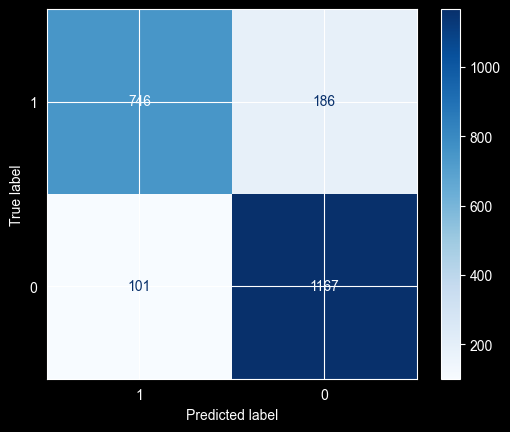

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
        pipe_1,
        X_test,
        y_test,
        display_labels=y_levels,
        cmap='Blues',
    )

746 mejlova je predviđeno kao spam od 932, dok je 101 mejlova predviđeno kao spam a zapravo nisu


1167 mejlova je predviđeno kao ne spam od 1268, dok je 186 predviđeno kao ne spam a zapravo jesu

In [114]:
from sklearn.metrics import classification_report
predictions_1 = pipe_1.predict(X_test)

report_1 = classification_report(y_true = y_test, y_pred = predictions_1,zero_division=0)
print(report_1)

              precision    recall  f1-score   support

           0       0.88      0.80      0.84       932
           1       0.86      0.92      0.89      1268

    accuracy                           0.87      2200
   macro avg       0.87      0.86      0.86      2200
weighted avg       0.87      0.87      0.87      2200



Preciznost govori da od svih mejlova, koje je model označio kao spam, 86% su zapravo spam, a od svih mejlova koje je model označio kao ne spam, 88% zapravo nisu spam

Odziv govori da od svih spam mejlova, model je uspeo da prepozna 92% spam mejlova, a od svih ne spam mejlova uspeo je da prepozna 80%

F1 skor odražava balans modela, visoki f1 skor odražava izbalansiranost modela

Tačnost, makro Tačnost i težinska tačnost iznose ~87%. To znači da model uspešno predviđa klasu u 87% slučajeva

Za testiranje hiper parametara korišćen je RandomizedSearch CrossValidate koji u velikom broju nasumičnih iteracija kreira više modela za različite kombinacije hiper parametara. Ponavljanjem ovog koraka i poređenjem sa GridSearchCV ustanovio sam da dobijam maltene svaki put isto rešenje za drastično manje vreme.

In [115]:
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

param_grid = {
    "classifier__alpha": [0.01, 0.1, 1.0],

    "vectorizer__subject_word_count__max_features": [500, 1000],
    "vectorizer__subject_word_count__min_df": [1, 2],
    "vectorizer__subject_word_count__max_df": [0.8, 0.9],

    "vectorizer__body_word_count__max_features": [2000, 5000],
    "vectorizer__body_word_count__min_df": [2, 5, 10],
    "vectorizer__body_word_count__max_df": [0.7, 0.8, 0.9],
}

r_search = RandomizedSearchCV(
    pipe_1,
    param_distributions=param_grid,
    scoring='f1',
    cv=5,
    n_iter=30,
    n_jobs=-1,
    verbose=2,
    error_score=0.0
)
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()
r_search.fit(X_train_copy,y_train_copy)
rmtree(cache)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Prikaz optimalnih hiperparametara

In [116]:
print('optimalni parametri: ', r_search.best_params_)
print('najbolji rezultat: ', r_search.best_score_)

optimalni parametri:  {'vectorizer__subject_word_count__min_df': 1, 'vectorizer__subject_word_count__max_features': 1000, 'vectorizer__subject_word_count__max_df': 0.8, 'vectorizer__body_word_count__min_df': 10, 'vectorizer__body_word_count__max_features': 5000, 'vectorizer__body_word_count__max_df': 0.7, 'classifier__alpha': 1.0}
najbolji rezultat:  0.8964980194027763


Zanimljivo zapažanje je da je našao

In [117]:
best_alpha = r_search.best_params_['classifier__alpha']

best_subject_min_df = r_search.best_params_['vectorizer__subject_word_count__min_df']
best_subject_max_features = r_search.best_params_['vectorizer__subject_word_count__max_features']
best_subject_max_df = r_search.best_params_['vectorizer__subject_word_count__max_df']

best_body_min_df = r_search.best_params_['vectorizer__body_word_count__min_df']
best_body_max_features = r_search.best_params_['vectorizer__body_word_count__max_features']
best_body_max_df = r_search.best_params_['vectorizer__body_word_count__max_df']


Postavljanje optimalnih hiperparametara

In [118]:
pipe_1.set_params(
    classifier__alpha=best_alpha,
    vectorizer__subject_word_count__min_df=best_subject_min_df,
    vectorizer__subject_word_count__max_features=best_subject_max_features,
    vectorizer__body_word_count__min_df=best_body_min_df,
    vectorizer__body_word_count__max_features=best_body_max_features
)
pipe_1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",'C:\\Users\\lukad\\AppD...ocal\\Temp\\tmpvj9xixrc'
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('subject_word_count', ...), ('body_word_count', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold

In [119]:
from sklearn.metrics import classification_report
predictions_2 = pipe_1.predict(X_test)

report_2 = classification_report(y_true = y_test, y_pred = predictions_2)
print(report_2)

              precision    recall  f1-score   support

           0       0.88      0.80      0.84       932
           1       0.86      0.92      0.89      1268

    accuracy                           0.87      2200
   macro avg       0.87      0.86      0.86      2200
weighted avg       0.87      0.87      0.87      2200



Nema promena u metrikama

Eksportovanje modela za zaključak

In [120]:
import joblib
joblib.dump(pipe_1, '../models/bow_mb_ceas.pkl')
joblib.dump(X_test, '../models/X_test_bow_mb_ceas.pkl')
joblib.dump(y_test, '../models/y_test_bow_mb_ceas.pkl')

['../models/y_test_bow_mb_ceas.pkl']